# wet bulb temperature empirical fit:
From "Wet-Bulb Temperature from Relative Humidity and Air Temperature", ROLAND STULL, 2011

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
from scipy import optimize

# a function that calculates WBT using an empirical fit:
rh=35 # percent
T=50 # celsius
def WBT(rh,T):
    # inputs - rh: percent, T: Celsius
    # output: T_w, Celsius
    Tw = T * np.arctan(0.151977 * (rh + 8.313659)**(1/2)) \
        + np.arctan(T + rh) - np.arctan(rh - 1.676331) \
        + 0.00391838 *(rh)**(3/2) * np.arctan(0.023101 * rh) \
        - 4.686035
    return Tw

print(WBT(rh,T))

35.158963495770124


# derivation from basic principles:
(Emanuel, Atmospheric convection, p 126, equation 4.6.4)

Conservation of total heat during the process of evaporating water into an air parcel,
\begin{align*}
    c_pT+L q=c_p T_w+L q^*(T_w)
\end{align*}
written in terms of relative humidity,
\begin{align*}
    c_pT+L\cdot RH\cdot q^*(T)=c_p T_w+Lq^*(T_w)
\end{align*}

In [2]:
# define a function that calculates WBT from the above heat budget

cp_dry  = 1005     # J/kg/K
c_p=1.0*cp_dry
L       = 24.93e5  # latent heat J/kg (vaporization at t.p.)
P=1000

def cost(T_w,rh,T):
    # rh - percent
    # T_w, T: Celsius
    J=(c_p*T+L*(rh/100)*q_sat(273.15+T,P))  -  (c_p*T_w+L*q_sat(273.15+T_w,P))
    return J


def q_sat(T,P):
    """
    Calculate saturation specific humidity (gr water vapor per gram moist air).
    inputs:
    T: temperature, in Kelvin
    P: pressure, in mb
    """
    R_v = 461 # Gas constant for moist air = 461 J/(kg*K)
    R_d = 287 # Gas constant 287 J K^-1 kg^-1
    TT = T-273.15 # Kelvin to Celsius
    # Saturation water vapor pressure (mb) from Emanuel 4.4.14 p 116-117: 
    ew = 6.112*np.exp((17.67 * TT) / (TT + 243.5))
    # saturation mixing ratio (gr water vapor per gram dry air):
    rw = (R_d / R_v) * ew / (P - ew)
    # saturation specific humidity (gr water vapor per gram moist air):
    qw = rw / (1 + rw)
    return qw

def my_WBT(rh,T):
    # input: scalars; rh: percent, T: Celsius
    sol = optimize.root(cost, T, args=(rh,T))
    T_w = sol.x[0]
    return T_w
    

print("T=",T,", rh=",rh,", WBT(rh,T)=",WBT(rh,T),", my_WBT(rh,T)=",my_WBT(rh,T))

T= 50 , rh= 35 , WBT(rh,T)= 35.158963495770124 , my_WBT(rh,T)= 34.40902633196082


In [3]:
# contour WBT(rh,T):

rh=np.arange(0,100.1,0.1)
T=np.arange(30,50.1,0.1)
x,y=np.meshgrid(T,rh)
WBT_plot=WBT(y,x)
my_WBT_plot=np.zeros(x.shape)

irh=-1
for rh1 in rh:
    irh=irh+1
    iT=-1
    for T1 in T:
        iT=iT+1
        my_WBT_plot[irh,iT]=my_WBT(rh1,T1)

print("done.")

done.


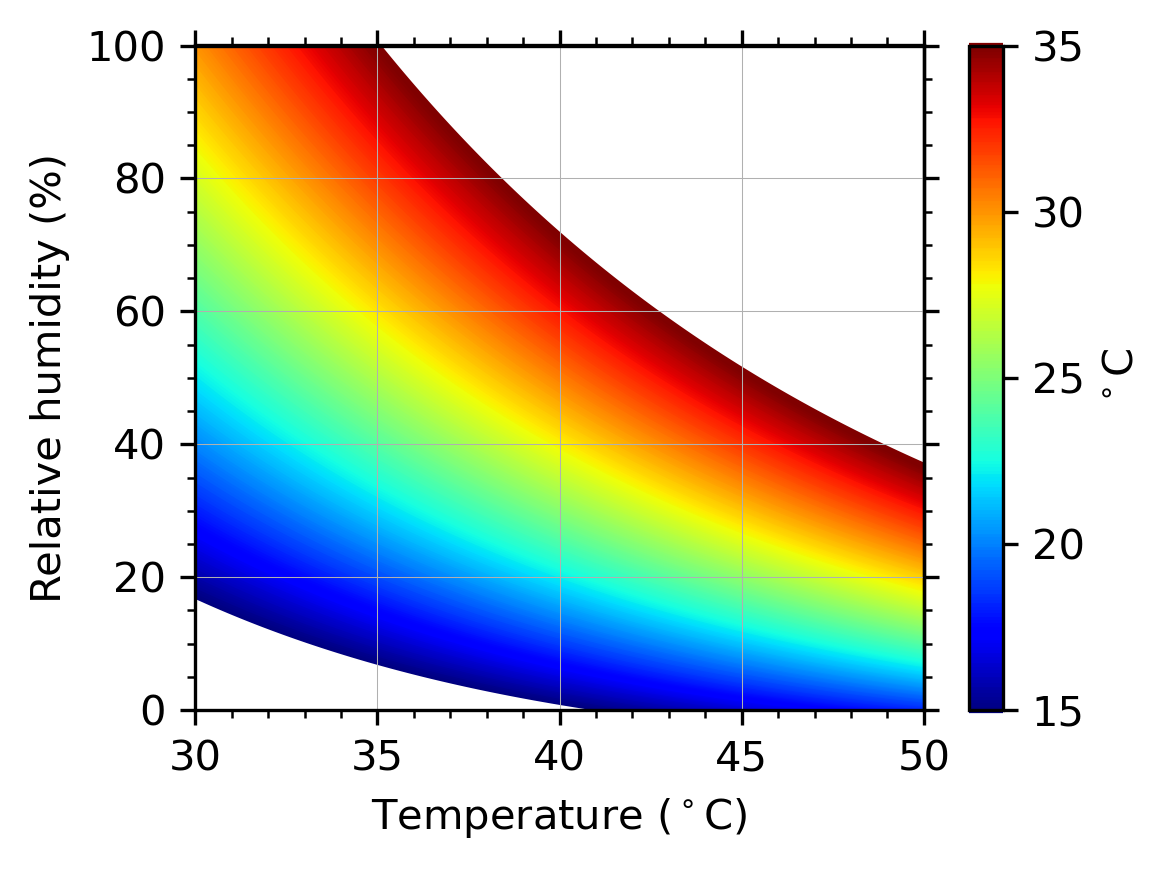

In [4]:
# plot WBT as function of RH and T:

fig=plt.figure(figsize=(4,3),dpi=300)
plt.set_cmap('jet')
levels=np.arange(15,35.1,0.1)
plt.contour(x,y,my_WBT_plot,levels=levels,zorder=-10)
hcb=plt.colorbar(label="${}^\\circ$C",ticks=range(15,40,5))
plt.grid(lw=0.25)
plt.xlabel("Temperature ($^\circ$C)")
plt.ylabel("Relative humidity (%)");
ax=plt.gca()
plt.xlim(30,50)
plt.ylim(0,100)
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(5))
ax2 = ax.secondary_xaxis('top')
ax3 = ax.secondary_yaxis('right')
ax2.xaxis.set_minor_locator(MultipleLocator(1))
ax3.yaxis.set_minor_locator(MultipleLocator(5))
ax2.tick_params(labeltop=False)
ax3.tick_params(labelright=False)
#plt.title("WBT")

plt.tight_layout()

/var/folders/0v/wvw14yq11b34jdy4j2h8fsx80000gn/T/ipykernel_8915/3725405685.py:8: UserWarning: linewidths is ignored by contourf
  plt.contourf(x,y,my_WBT_plot-WBT_plot,linestyles="--",linewidths=0.5,levels=20)


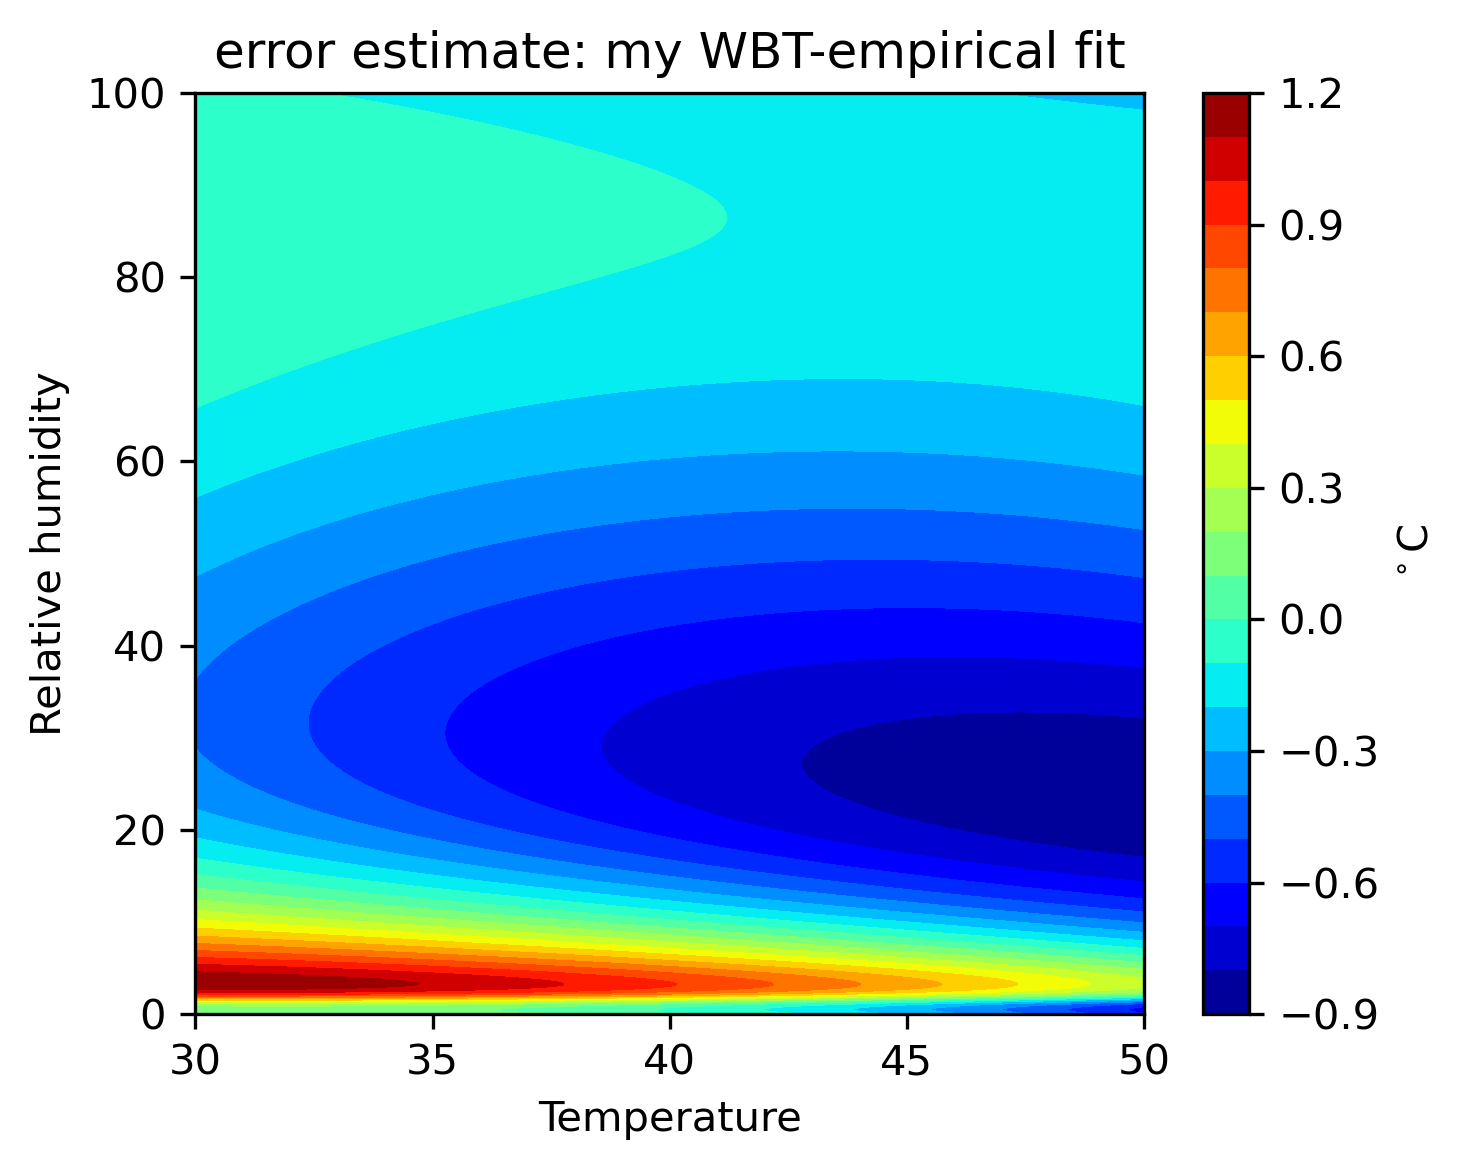

In [5]:
# plot error estimate:

fig=plt.figure(figsize=(5,4),dpi=300)
ax=plt.gca()
plt.set_cmap('jet')
levels=np.arange(15,37,0.1)
levels1=np.arange(15,37,2)
plt.contourf(x,y,my_WBT_plot-WBT_plot,linestyles="--",linewidths=0.5,levels=20)
hcb=plt.colorbar(label="${}^\\circ$C")
plt.xlabel("Temperature")
plt.ylabel("Relative humidity");
plt.title("error estimate: my WBT-empirical fit");

plt.tight_layout()